# Customer Segmentation & Retention Analysis
### Online Retail II Dataset – RFM-Analyse

**Ziel:** Kunden nach Kaufverhalten segmentieren, um Handlungsempfehlungen
zur Kundenbindung abzuleiten.

**Datenquelle:** UCI Machine Learning Repository, Online Retail II
(Dez 2009 – Dez 2011, UK-Online-Händler) https://archive.ics.uci.edu/dataset/502/online+retail+ii

## 1. Daten laden & erster Überblick

In [28]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np

# Beide Sheets einzeln laden...
sheet_2009 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2009-2010')
sheet_2010 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')

# ...und zu EINEM DataFrame zusammenführen (untereinander hängen)
df = pd.concat([sheet_2009, sheet_2010], ignore_index=True)

print(df.shape)          # (Zeilen, Spalten)
print(df.dtypes)         # Datentyp jeder Spalte prüfen
print(df.isnull().sum()) # Fehlende Werte PRO SPALTE (nicht nur total!)


Saving online_retail_II.xlsx to online_retail_II (1).xlsx
(1067371, 8)
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


## 2. Datenbereinigung
Rohdaten enthalten Duplikate, fehlende Customer IDs, Stornos und
fehlerhafte Werte. Diese werden schrittweise entfernt.

In [29]:
# Wie viele Zeilen wir vor der Bereinigung hatten (zum Vergleich später)
n_start = len(df)
print("Start:", n_start)

# 1) Duplikate entfernen
df = df.drop_duplicates()
print("Nach Duplikate entfernen:", len(df))

# 2) Zeilen ohne Customer ID entfernen
df = df.dropna(subset=['Customer ID'])
print("Nach fehlende Customer ID entfernen:", len(df))

# 3) Stornierte Bestellungen entfernen (Invoice beginnt mit 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]
print("Nach Stornos entfernen:", len(df))

# 4) Negative/Null-Werte bei Quantity/Price entfernen
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
print("Nach negative Werte entfernen:", len(df))

# 5) Customer ID als Integer speichern (vorher war es float, z.B. 13085.0)
df['Customer ID'] = df['Customer ID'].astype(int)

# 6) Neue Umsatz-Spalte berechnen (Menge × Preis)
df['Revenue'] = df['Quantity'] * df['Price']

print("\nFinale Zeilenanzahl:", len(df), f"({len(df)/n_start*100:.1f}% der Rohdaten)")

# Kontrolle: sieht der DataFrame jetzt gut aus?
df.head()

Start: 1067371
Nach Duplikate entfernen: 1033036
Nach fehlende Customer ID entfernen: 797885
Nach Stornos entfernen: 779495
Nach negative Werte entfernen: 779425

Finale Zeilenanzahl: 779425 (73.0% der Rohdaten)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


## 3. RFM-Analyse
Berechnung von Recency, Frequency und Monetary pro Kunde als Basis
für die Segmentierung.

In [30]:
# Wir brauchen einen "heutigen Tag", um zu berechnen, wie lange ein Kauf her ist.
# Da die Daten aus der Vergangenheit sind, nehmen wir den letzten Tag im Datensatz + 1 Tag

letztes_datum = df['InvoiceDate'].max()
referenz_datum = letztes_datum + pd.Timedelta(days=1)

print(letztes_datum)     # letzter Kauf im gesamten Datensatz
print(referenz_datum)    # unser "heute" für die Berechnung

2011-12-09 12:50:00
2011-12-10 12:50:00


In [31]:
# Letzter Kaufzeitpunkt pro Kunde finden
letzter_kauf_pro_kunde = df.groupby('Customer ID')['InvoiceDate'].max()

# Differenz zum Referenzdatum in Tagen
recency = (referenz_datum - letzter_kauf_pro_kunde).dt.days

print(recency.head())

Customer ID
12346    326
12347      2
12348     75
12349     19
12350    310
Name: InvoiceDate, dtype: int64


In [32]:
# Anzahl EINDEUTIGER Bestellungen pro Kunde
frequency = df.groupby('Customer ID')['Invoice'].nunique()

print(frequency.head())

Customer ID
12346    12
12347     8
12348     5
12349     4
12350     1
Name: Invoice, dtype: int64


In [33]:
# Gesamtumsatz pro Kunde
monetary = df.groupby('Customer ID')['Revenue'].sum()

print(monetary.head())

Customer ID
12346    77556.46
12347     4921.53
12348     2019.40
12349     4428.69
12350      334.40
Name: Revenue, dtype: float64


In [34]:
rfm = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary
})

print(rfm.head())
print(rfm.describe())

             Recency  Frequency  Monetary
Customer ID                              
12346            326         12  77556.46
12347              2          8   4921.53
12348             75          5   2019.40
12349             19          4   4428.69
12350            310          1    334.40
           Recency    Frequency       Monetary
count  5878.000000  5878.000000    5878.000000
mean    201.331916     6.289384    2955.904095
std     209.338707    13.009406   14440.852688
min       1.000000     1.000000       2.950000
25%      26.000000     1.000000     342.280000
50%      96.000000     3.000000     867.740000
75%     380.000000     7.000000    2248.305000
max     739.000000   398.000000  580987.040000


In [35]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

print(rfm.head(10))

             Recency  Frequency  Monetary R_Score F_Score M_Score
Customer ID                                                      
12346            326         12  77556.46       2       5       5
12347              2          8   4921.53       5       4       5
12348             75          5   2019.40       3       4       4
12349             19          4   4428.69       5       3       5
12350            310          1    334.40       2       1       2
12351            375          1    300.93       2       1       2
12352             36         10   2849.84       4       5       4
12353            204          2    406.76       2       2       2
12354            232          1   1079.40       2       1       3
12355            214          2    947.61       2       2       3


## 4. Kundensegmentierung
Kunden werden anhand ihres RFM-Scores in 5 Segmente eingeteilt:
Champions, Treue Kunden, Braucht Aufmerksamkeit, Abwanderungsgefahr, Verloren.

In [36]:
# Die Scores sind noch als "Kategorie" gespeichert, wir machen daraus normale Zahlen
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

# Alle drei Scores zusammenzählen (kann zwischen 3 und 15 liegen)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

# Eine Funktion schreiben, die je nach Gesamt-Score einen Namen zurückgibt
def segment_zuweisen(score):
    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Treue Kunden'
    elif score >= 7:
        return 'Braucht Aufmerksamkeit'
    elif score >= 4:
        return 'Abwanderungsgefahr'
    else:
        return 'Verloren'

# Die Funktion auf jede Zeile der RFM_Score-Spalte anwenden
rfm['Segment'] = rfm['RFM_Score'].apply(segment_zuweisen)

print(rfm.head(10))


             Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
Customer ID                                                            
12346            326         12  77556.46        2        5        5   
12347              2          8   4921.53        5        4        5   
12348             75          5   2019.40        3        4        4   
12349             19          4   4428.69        5        3        5   
12350            310          1    334.40        2        1        2   
12351            375          1    300.93        2        1        2   
12352             36         10   2849.84        4        5        4   
12353            204          2    406.76        2        2        2   
12354            232          1   1079.40        2        1        3   
12355            214          2    947.61        2        2        3   

             RFM_Score                 Segment  
Customer ID                                     
12346               12            Tre

## 5. Umsatzverteilung nach Segment

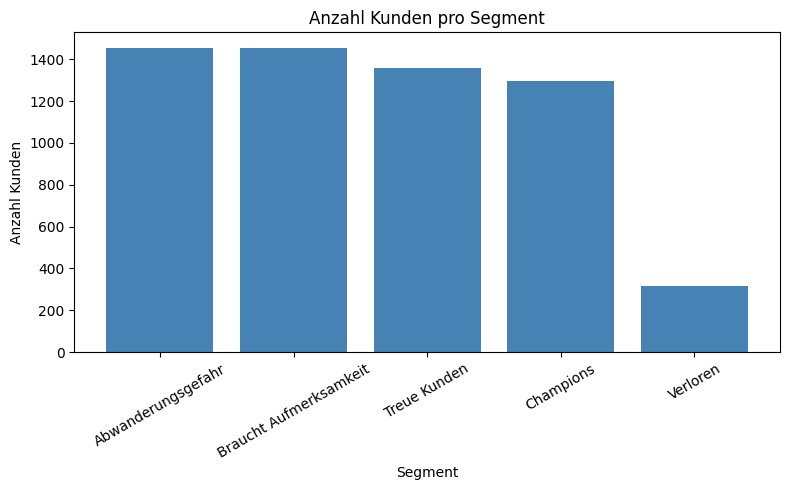

In [37]:
import matplotlib.pyplot as plt

# Wie viele Kunden pro Segment zählen
segment_anzahl = rfm['Segment'].value_counts()

# Balkendiagramm erstellen
plt.figure(figsize=(8, 5))
plt.bar(segment_anzahl.index, segment_anzahl.values, color='steelblue')
plt.title('Anzahl Kunden pro Segment')
plt.xlabel('Segment')
plt.ylabel('Anzahl Kunden')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('segment_chart.png')
plt.show()

Segment
Champions                 1.253323e+07
Treue Kunden              3.070957e+06
Braucht Aufmerksamkeit    1.238840e+06
Abwanderungsgefahr        4.861270e+05
Verloren                  4.565043e+04
Name: Monetary, dtype: float64


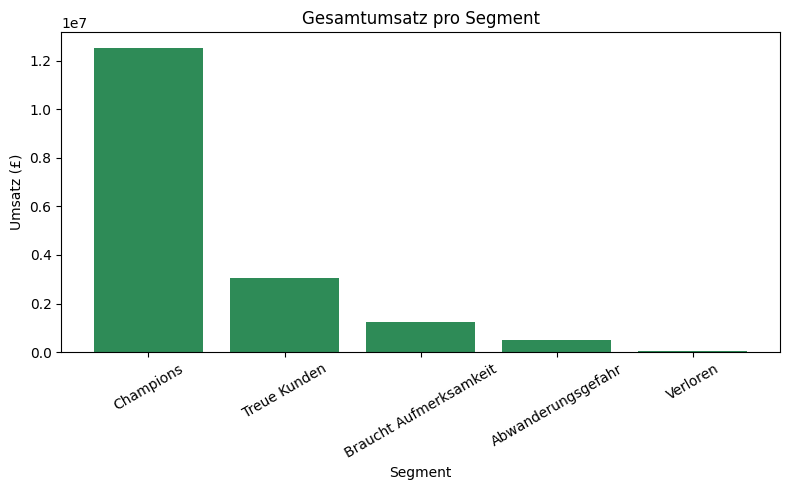

In [38]:
# Umsatz pro Segment zusammenzählen
umsatz_pro_segment = rfm.groupby('Segment')['Monetary'].sum()

# Nach größtem Umsatz sortieren (damit das Chart schöner aussieht)
umsatz_pro_segment = umsatz_pro_segment.sort_values(ascending=False)

print(umsatz_pro_segment)

# Balkendiagramm zeichnen
plt.figure(figsize=(8, 5))
plt.bar(umsatz_pro_segment.index, umsatz_pro_segment.values, color='seagreen')
plt.title('Gesamtumsatz pro Segment')
plt.xlabel('Segment')
plt.ylabel('Umsatz (£)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('umsatz_segment_chart.png')
plt.show()

In [39]:
# Gesamtumsatz von ALLEN Kunden zusammen
gesamt_umsatz = rfm['Monetary'].sum()

# Jeden Segment-Umsatz durch den Gesamtumsatz teilen = Anteil
anteil_prozent = (umsatz_pro_segment / gesamt_umsatz) * 100

print(anteil_prozent.round(1))

Segment
Champions                 72.1
Treue Kunden              17.7
Braucht Aufmerksamkeit     7.1
Abwanderungsgefahr         2.8
Verloren                   0.3
Name: Monetary, dtype: float64


### 🔑 Wichtigste Erkenntnis
22% der Kunden (Champions) generieren **72% des Gesamtumsatzes** –
ein klassisches Pareto-Prinzip. Diese Gruppe sollte höchste Priorität
bei Kundenbindungsmaßnahmen erhalten.

## 6. Cohort-Analyse (Retention über Zeit)

In [40]:
# Aus dem genauen Datum (z.B. 2010-03-15 14:30) nur den Monat rausziehen (2010-03)
df['Bestellmonat'] = df['InvoiceDate'].dt.to_period('M')

df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Bestellmonat
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12


In [41]:
# Fuer jeden Kunden den FRUEHESTEN Bestellmonat finden
erste_kaeufe = df.groupby('Customer ID')['Bestellmonat'].min()

# Diesen ersten Monat als neue Spalte an jede Zeile anhaengen
df['Cohort_Monat'] = df['Customer ID'].map(erste_kaeufe)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Bestellmonat,Cohort_Monat
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12,2009-12


In [42]:
# Differenz zwischen Bestellmonat und Cohort-Monat berechnen (in Monaten)
df['Monats_Nummer'] = (df['Bestellmonat'] - df['Cohort_Monat']).apply(lambda x: x.n)

df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Bestellmonat,Cohort_Monat,Monats_Nummer
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12,2009-12,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,2009-12,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,2009-12,0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12,2009-12,0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12,2009-12,0
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085,United Kingdom,39.6,2009-12,2009-12,0
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12,2009-12,0
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085,United Kingdom,59.5,2009-12,2009-12,0
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085,United Kingdom,30.6,2009-12,2009-12,0
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085,United Kingdom,45.0,2009-12,2009-12,0


In [43]:
# Pro Cohort-Monat und Monats_Nummer zaehlen, wie viele EINZIGARTIGE Kunden aktiv waren
cohort_daten = df.groupby(['Cohort_Monat', 'Monats_Nummer'])['Customer ID'].nunique()
cohort_daten = cohort_daten.reset_index()

cohort_daten.head(10)

,Cohort_Monat,Monats_Nummer,Customer ID
0,2009-12,0,955
1,2009-12,1,337
2,2009-12,2,319
3,2009-12,3,406
4,2009-12,4,363
5,2009-12,5,343
6,2009-12,6,360
7,2009-12,7,327
8,2009-12,8,321
9,2009-12,9,346


In [44]:
# Zeilen = Cohort-Monat, Spalten = Monats_Nummer, Werte = Anzahl Kunden
cohort_tabelle = cohort_daten.pivot(index='Cohort_Monat', columns='Monats_Nummer', values='Customer ID')

cohort_tabelle

Monats_Nummer,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
Cohort_Monat,,,,,,,,,,,,,,,,,,,,,
2009-12,955.0,337.0,319.0,406.0,363.0,343.0,360.0,327.0,321.0,346.0,...,289.0,251.0,289.0,270.0,248.0,244.0,301.0,291.0,389.0,188.0
2010-01,383.0,79.0,119.0,117.0,101.0,115.0,99.0,88.0,107.0,122.0,...,58.0,90.0,76.0,71.0,75.0,93.0,74.0,94.0,22.0,NaN
2010-02,374.0,89.0,84.0,109.0,92.0,75.0,72.0,107.0,95.0,103.0,...,75.0,60.0,61.0,54.0,86.0,86.0,61.0,22.0,NaN,NaN
2010-03,443.0,84.0,102.0,107.0,103.0,90.0,109.0,134.0,122.0,48.0,...,75.0,77.0,69.0,78.0,89.0,94.0,35.0,NaN,NaN,NaN
2010-04,294.0,57.0,57.0,48.0,54.0,66.0,81.0,77.0,31.0,32.0,...,46.0,41.0,44.0,53.0,66.0,17.0,NaN,NaN,NaN,NaN
2010-05,254.0,40.0,43.0,44.0,45.0,65.0,54.0,32.0,15.0,21.0,...,32.0,35.0,42.0,39.0,12.0,NaN,NaN,NaN,NaN,NaN
2010-06,270.0,47.0,51.0,55.0,62.0,77.0,34.0,24.0,22.0,32.0,...,33.0,36.0,55.0,14.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,186.0,29.0,34.0,55.0,54.0,26.0,21.0,27.0,27.0,21.0,...,32.0,44.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,162.0,33.0,48.0,52.0,28.0,19.0,16.0,20.0,22.0,21.0,...,32.0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
# Erste Spalte (Monat 0) = Startgroesse jeder Cohort
cohort_groesse = cohort_tabelle.iloc[:, 0]

# Jede Zeile durch ihre eigene Startgroesse teilen = Prozent-Retention
retention = cohort_tabelle.divide(cohort_groesse, axis=0) * 100

retention.round(1)

Monats_Nummer,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
Cohort_Monat,,,,,,,,,,,,,,,,,,,,,
2009-12,100.0,35.3,33.4,42.5,38.0,35.9,37.7,34.2,33.6,36.2,...,30.3,26.3,30.3,28.3,26.0,25.5,31.5,30.5,40.7,19.7
2010-01,100.0,20.6,31.1,30.5,26.4,30.0,25.8,23.0,27.9,31.9,...,15.1,23.5,19.8,18.5,19.6,24.3,19.3,24.5,5.7,NaN
2010-02,100.0,23.8,22.5,29.1,24.6,20.1,19.3,28.6,25.4,27.5,...,20.1,16.0,16.3,14.4,23.0,23.0,16.3,5.9,NaN,NaN
2010-03,100.0,19.0,23.0,24.2,23.3,20.3,24.6,30.2,27.5,10.8,...,16.9,17.4,15.6,17.6,20.1,21.2,7.9,NaN,NaN,NaN
2010-04,100.0,19.4,19.4,16.3,18.4,22.4,27.6,26.2,10.5,10.9,...,15.6,13.9,15.0,18.0,22.4,5.8,NaN,NaN,NaN,NaN
2010-05,100.0,15.7,16.9,17.3,17.7,25.6,21.3,12.6,5.9,8.3,...,12.6,13.8,16.5,15.4,4.7,NaN,NaN,NaN,NaN,NaN
2010-06,100.0,17.4,18.9,20.4,23.0,28.5,12.6,8.9,8.1,11.9,...,12.2,13.3,20.4,5.2,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,100.0,15.6,18.3,29.6,29.0,14.0,11.3,14.5,14.5,11.3,...,17.2,23.7,8.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,100.0,20.4,29.6,32.1,17.3,11.7,9.9,12.3,13.6,13.0,...,19.8,6.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


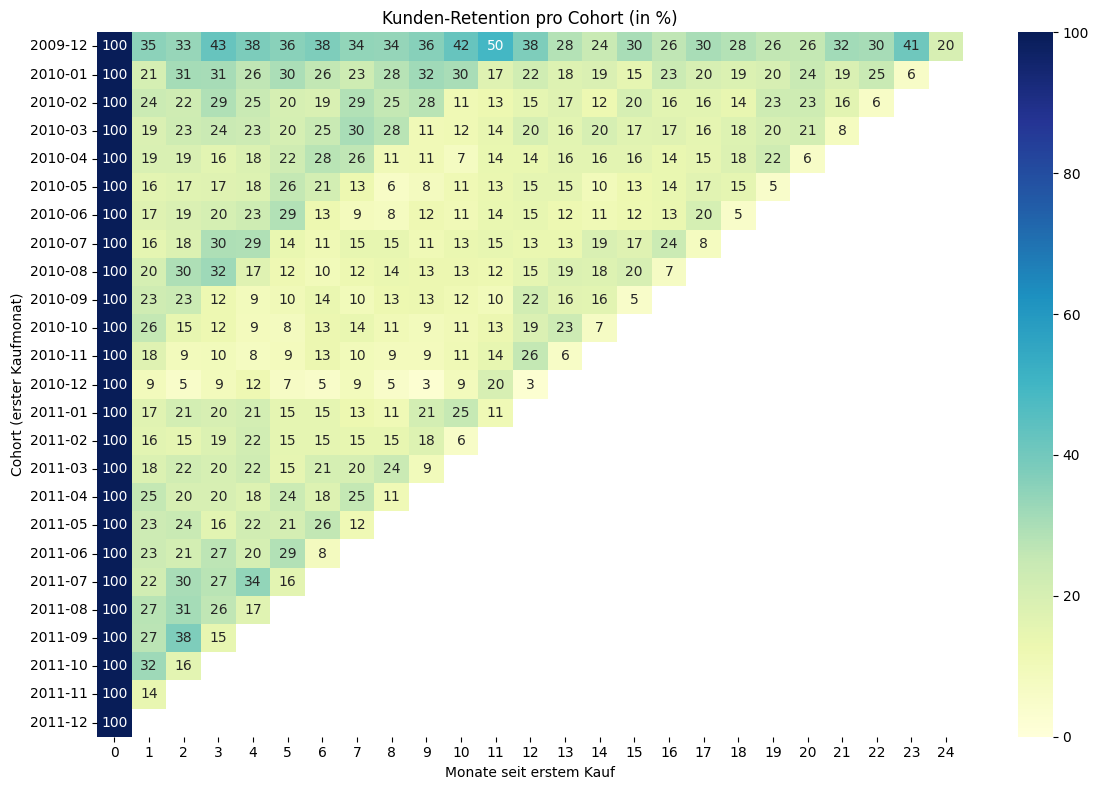

In [46]:
# Cohort-Monat in normalen Text umwandeln (fuer schoenere Beschriftung im Chart)
retention.index = retention.index.astype(str)

import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(retention, annot=True, fmt='.0f', cmap='YlGnBu', vmin=0, vmax=100)
plt.title('Kunden-Retention pro Cohort (in %)')
plt.xlabel('Monate seit erstem Kauf')
plt.ylabel('Cohort (erster Kaufmonat)')
plt.tight_layout()
plt.savefig('retention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Fazit & Handlungsempfehlungen


**Zusammenfassung:**
Von den ursprünglich über 1 Million Bestellzeilen blieben nach der Bereinigung
ca. 780.000 übrig (73%). Die Analyse zeigt: Eine kleine Gruppe von Kunden
("Champions", 22% aller Kunden) macht **72% des gesamten Umsatzes** aus.
Außerdem zeigt die Cohort-Analyse, dass neue Kunden schneller aufhören zu
kaufen als die allerersten Kunden im Datensatz. Es gibt zudem einen
wiederkehrenden Effekt um Monat 11-12 – vermutlich kommen Kunden zur
Weihnachtszeit zurück.

**Handlungsempfehlungen:**

1. **Top-Kunden besonders gut behandeln** – Die "Champions" bringen den
   meisten Umsatz. Ein VIP-Programm oder persönlicher Kontakt könnte
   verhindern, dass diese wichtigen Kunden abwandern.
   
2. **Kunden mit Abwanderungsgefahr zurückholen** – Diese Gruppe ist noch
   nicht verloren. Einfache, günstige Maßnahmen wie Erinnerungs-E-Mails
   könnten reichen, um sie zurückzuholen.
   
3. **Neue Kunden besser einbinden** – Da neue Kunden schneller abspringen,
   könnte ein Rabatt für die zweite Bestellung helfen, sie länger zu halten.
   
4. **Weihnachtszeit gezielt nutzen** – Da viele Kunden um diese Zeit
   zurückkommen, sollten Marketing-Aktionen schon einige Wochen vorher
   starten.

**Einschränkung der Analyse:**
Ein paar sehr große Bestellungen (wahrscheinlich Großhändler) wurden nicht
extra behandelt. Eine getrennte Analyse für Privat- und Großkunden wäre
ein guter nächster Schritt.

**Verwendete Tools:** Python (Pandas, Matplotlib, Seaborn), SQL (SQLite)

##RFM-Berechnung mit SQL

In [47]:
import sqlite3

# Nur die Spalten auswaehlen, die wir fuer SQL brauchen (keine Period-Spalten!)
df_fuer_sql = df[['Customer ID', 'Invoice', 'InvoiceDate', 'Revenue']].copy()

# Jetzt in die Datenbank schreiben
verbindung = sqlite3.connect('retail.db')
df_fuer_sql.to_sql('transaktionen', verbindung, if_exists='replace', index=False)

# Testen
test = pd.read_sql("SELECT * FROM transaktionen LIMIT 5", verbindung)
test

,Customer ID,Invoice,InvoiceDate,Revenue
0,13085,489434,2009-12-01 07:45:00,83.4
1,13085,489434,2009-12-01 07:45:00,81.0
2,13085,489434,2009-12-01 07:45:00,81.0
3,13085,489434,2009-12-01 07:45:00,100.8
4,13085,489434,2009-12-01 07:45:00,30.0
